In [2]:
# 套件導入
#====================================================================
#====================================================================
import copy
import gc
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
import threading
import transformers
import torch
import torch.nn as nn
import urllib.request
import warnings

from collections import Counter
from sklearn.metrics import classification_report, f1_score
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification,BertModel,BertTokenizer, RobertaModel, get_linear_schedule_with_warmup
from sklearn.model_selection import KFold

print( "套件導入完成" )

套件導入完成


In [3]:
# error過濾
#====================================================================
#====================================================================
def silence_transformers_background_noise(args):
    if args.thread and args.thread.name == "Thread-auto_conversion":
        return
    if hasattr(sys, "__excepthook__") and sys.__excepthook__ is not None:
        sys.__excepthook__(args)
    else:
        print(f"Exception in thread {args.thread.name}: {args.exc_value}", file=sys.stderr)

threading.excepthook = silence_transformers_background_noise
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

print("背景雜訊過濾")

背景雜訊過濾


In [4]:
#環境測試
#====================================================================
#====================================================================

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"當前 GPU 裝置: {torch.cuda.get_device_name(0)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch 版本: 2.10.0+cu128
CUDA 是否可用: True
當前 GPU 裝置: Tesla T4


In [5]:
#參數設定
#====================================================================
#====================================================================
# ===== 檔案相關設定 =====
KAGGLE_INPUT_DIR = "/kaggle/input/datasets/yuek666/esg-dataset"
train_path_1 = os.path.join(KAGGLE_INPUT_DIR, "vpesg4ktrain1000v1.json")
train_path_2 = os.path.join(KAGGLE_INPUT_DIR, "vpesg4k_val_1000.json")
KAGGLE_DATASET_DIR = "/kaggle/input/datasets/yuek666/esg-dataset"
test_json_path = os.path.join(KAGGLE_DATASET_DIR, "vpesg4k_test_2000.json")
test_csv_path = os.path.join(KAGGLE_DATASET_DIR, "vpesg4k_test_2000.csv")
MODEL_SAVE_DIR = "ensemble_models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)



# 確保兩個檔案都存在才進行讀取與合併
if os.path.exists(train_path_1) and os.path.exists(train_path_2):
    with open(train_path_1, "r", encoding="utf-8") as f:
        data_1 = json.load(f)
    with open(train_path_2, "r", encoding="utf-8") as f:
        data_2 = json.load(f)
        
    # 兩個資料集串接合併（1000 筆 + 1000 筆 = 2000 筆）
    combined_data = data_1 + data_2
    
    # 將合併後的資料儲存到當前工作目錄，供後續全域變數或讀取使用
    LOAD_DATA = "vpesg4k_combined_2000.json"
    with open(LOAD_DATA, "w", encoding="utf-8") as f:
        json.dump(combined_data, f, ensure_ascii=False, indent=2)
        
    print(f"資料載入與合併完成！")
    print(f"   - 檔案一 ({os.path.basename(train_path_1)}): {len(data_1)} 筆")
    print(f"   - 檔案二 ({os.path.basename(train_path_2)}): {len(data_2)} 筆")
    print(f"   - 合併後總計: {len(combined_data)} 筆，已暫存至 '{LOAD_DATA}'")
else:
    raise FileNotFoundError(f"找不到指定的 Kaggle 輸入檔案，請檢查 Dataset 是否正確掛載！\n路徑 1: {train_path_1}\n路徑 2: {train_path_2}")
    
# ===== 超參數 =====
MODEL_NAME = "hfl/chinese-roberta-wwm-ext"
MAX_LEN = 512
BATCH_SIZE = 16    # 資料集較小（1000筆），使用小 batch size
EPOCHS = 10       # 資料少，多訓練幾個 epoch
LR = 2e-5
K_FOLDS = 5

# ===== 預測欄位設定 =====
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "more_than_5_years", "longer_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}
# ===== 欄位評分 =====
FIELD_WEIGHTS = {
    "promise_status": 0.2,
    "verification_timeline": 0.15,
    "evidence_status": 0.3,
    "evidence_quality": 0.35
}
# ===== 標籤 -> ID 映射 =====

label2id = {}
id2label = {}
num_labels = {}

for field, labels in EVAL_FIELDS.items():
    if field == "verification_timeline":
        label2id[field] = {
            "already": 0,
            "within_2_years": 1,
            "between_2_and_5_years": 2,
            "more_than_5_years": 3,
            "longer_than_5_years": 3,  
            "N/A": 4
        }
        # 反向還原字典：拿掉 longer_than_5_years。當模型預測出 3，轉回官方的 'more_than_5_years'
        id2label[field] = {
            0: "already",
            1: "within_2_years",
            2: "between_2_and_5_years",
            3: "more_than_5_years",   
            4: "N/A"
        }
        num_labels[field] = 5  # 扣除重複後，實質上此任務的分類輸出層只需要 5 個神經元
    else:
        # 其他不影響的欄位保持原樣自動生成
        label2id[field] = {label: i for i, label in enumerate(labels)}
        id2label[field] = {i: label for i, label in enumerate(labels)}
        num_labels[field] = len(labels)



print('超參數設定完成！')
print(f'使用模型: {MODEL_NAME}')
print(f'最大長度: {MAX_LEN}')
print(f'批次大小: {BATCH_SIZE}')
print(f'訓練輪數: {EPOCHS}')
print(f'標籤數量: {num_labels}')
print(f"集成設定：將訓練 {K_FOLDS} 個模型進行投票集成。")

資料載入與合併完成！
   - 檔案一 (vpesg4ktrain1000v1.json): 1000 筆
   - 檔案二 (vpesg4k_val_1000.json): 1000 筆
   - 合併後總計: 2000 筆，已暫存至 'vpesg4k_combined_2000.json'
超參數設定完成！
使用模型: hfl/chinese-roberta-wwm-ext
最大長度: 512
批次大小: 16
訓練輪數: 10
標籤數量: {'promise_status': 2, 'verification_timeline': 5, 'evidence_status': 3, 'evidence_quality': 4}
集成設定：將訓練 5 個模型進行投票集成。


In [6]:
# 資料仔入與Kfold初始化
#====================================================================
#====================================================================
with open(LOAD_DATA, "r", encoding="utf-8") as f:
    all_data = json.load(f)

# 將 list 轉成 numpy array，方便後續透過索引（Index）進行 K-Fold 切片
all_data_np = np.array(all_data)

# 初始化 KFold 產生器
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"資料總數：{len(all_data_np)} 筆")
print(f"設定集成參數：K = {K_FOLDS}，每個 Fold 將分配到 {len(all_data_np)//K_FOLDS} 筆驗證資料。")

資料總數：2000 筆
設定集成參數：K = 5，每個 Fold 將分配到 400 筆驗證資料。


範例資料欄位：
--------------------------------------------------
  id: 10001
  data: 聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性...
  esg_type: S
  promise_status: Yes
  promise_string: 為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性員工則可於其配偶懷孕期間陪同產檢或生（流）產日及前後 15 日間請假陪伴，兩者合計共有 10 天陪產（檢）假可運用，陪產（檢）假期間工資照常給付。
  verification_timeline: already
  evidence_status: No
  evidence_string: 
  evidence_quality: N/A
  company: mediatek
  ticker: 2454
  page_number: 48
  pdf_url: https://hsxn1sjvkgtdpixe.public.blob.vercel-storage.com/mediatek_2454_page_48.pdf
  company_source: https://corp.mediatek.tw/about/sustainability

資料欄位類型：
id                       object
data                     object
esg_type                 object
promise_status           object
promise_string           object
verification_timeline    object
evidence_status          object
evidence_string          object
evidence_quality         object
company                  o

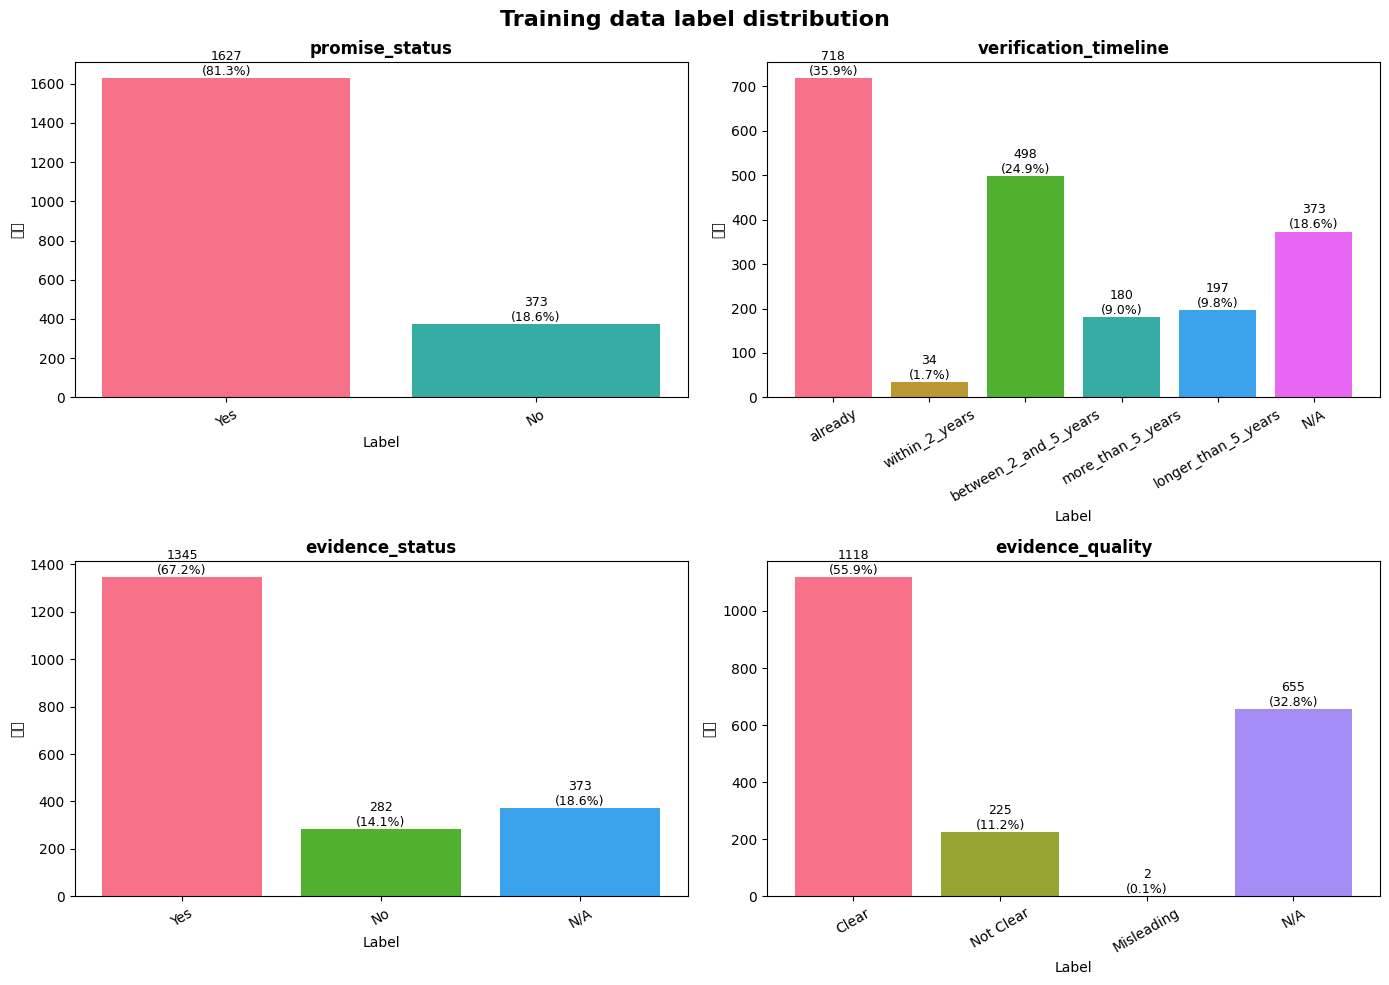

觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數


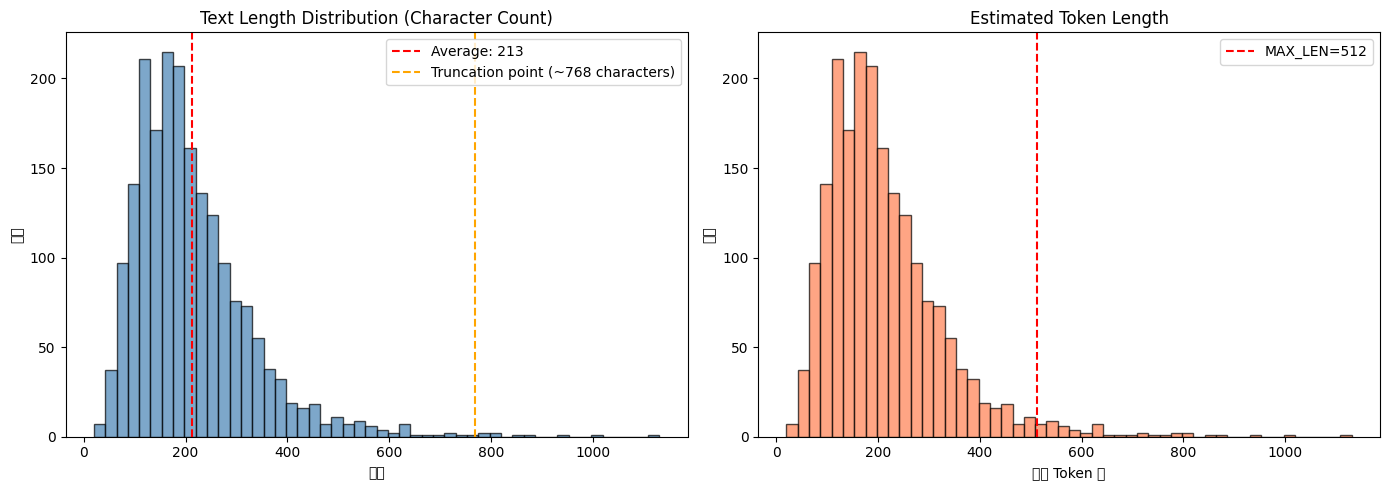

超過 MAX_LEN=512 的樣本數: 50 (2.5%)
   這些文字將被截斷，可能損失尾端資訊


In [7]:
#視覺化資料
#====================================================================
#====================================================================
# 觀察單筆資料結構
# ===== 範例資料結構顯示  ===== 最多100字
sample = all_data_np[0]
print("範例資料欄位：")
print("-" * 50)
for key, value in sample.items():
    if key == "data":
        print(f"  {key}: {str(value)[:100]}...")
    else:
        print(f"  {key}: {value}")

# 轉換為 DataFrame 方便分析
train_df = pd.DataFrame(all_data_np.tolist())

print("\n資料欄位類型：")
print(train_df.dtypes)
print(f"\n資料集所有欄位：{list(train_df.columns)}")

# ===== 資料欄位標籤顯示 =====
# 視覺化各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training data label distribution", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    counts = Counter(train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("husl", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Label")
    ax.set_ylabel("數量")  
    ax.tick_params(axis='x', rotation=30)

    # 在每個 bar 上顯示數量與比例
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        total = sum(ordered_counts.values())
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數")

# ===== 文字長度分布顯示 =====
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：字元長度分佈
axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"Average: {train_df['text_length'].mean():.0f}")
axes[0].axvline(MAX_LEN * 1.5, color='orange', linestyle='--',
                label=f"Truncation point (~{MAX_LEN * 1.5:.0f} characters)")
axes[0].set_title("Text Length Distribution (Character Count)")
axes[0].set_xlabel("字元")  
axes[0].set_ylabel("數量")  
axes[0].legend()

# 右圖：Token 長度估算
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f"MAX_LEN={MAX_LEN}")
axes[1].set_title("Estimated Token Length")
axes[1].set_xlabel("預估 Token 數")  
axes[1].set_ylabel("數量")          
axes[1].legend()

plt.tight_layout()
plt.show()

# ===========
truncated = (train_df['text_length'] > MAX_LEN).sum()
print(f"超過 MAX_LEN={MAX_LEN} 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")
print(f"   這些文字將被截斷，可能損失尾端資訊")

In [8]:
#Tokenizer 示範
#====================================================================
#====================================================================
print('Tokenizer 示範')
print('=' * 50)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'載入 {MODEL_NAME} tokenizer')

sample_text = all_data_np[0]['data'][:50]
print(f'原始文字：{sample_text}')

tokens = tokenizer.tokenize(sample_text)
print(f'Tokenize 後：{tokens}')

encoding = tokenizer(sample_text, max_length=20, padding='max_length', truncation=True)
print(f"Input IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")

Tokenizer 示範


tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

載入 hfl/chinese-roberta-wwm-ext tokenizer
原始文字：聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其
Tokenize 後：['聯', '發', '科', '技', '除', '在', '「', '工', '作', '規', '則', '」', '中', '依', '照', '勞', '基', '法', '明', '確', '規', '定', '「', '員', '工', '在', '產', '假', '期', '間', '公', '司', '不', '得', '終', '止', '勞', '動', '契', '約', '」', '外', '，', '為', '支', '持', '同', '仁', '與', '其']
Input IDs (前20個)：[101, 5474, 4634, 4906, 2825, 7370, 1762, 519, 2339, 868, 6211, 1179, 520, 704, 898, 4212, 1246, 1825, 3791, 102]
Attention Mask：[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [9]:
class ESGDataset(Dataset):
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['data']

        # Tokenize 輸入文字
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # 轉換所有任務的標籤為 ID（優化防呆版：完美相容無答案欄位的測試集）
        labels = {}
        for field, mapping in self.label2id.items():
            # 檢查該 ESG 任務欄位是否存在於資料中
            if field in sample:
                label_text = sample[field]
                labels[field] = torch.tensor(mapping[label_text], dtype=torch.long)
            else:
                # 測試集無答案，給予 -1 作為 Dummy 值，確保 Data Pipeline 與模型架構對齊不中斷
                labels[field] = torch.tensor(-1, dtype=torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

print("ESGDataset fin！")

ESGDataset fin！


In [10]:
#batch 傳入模型//?waitttt
#====================================================================
#====================================================================
def collate_fn(batch):
    
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])

    labels = {
        field: torch.stack([item['labels'][field] for item in batch])
        for field in EVAL_FIELDS
    }

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }
print("collate_fn fin")

collate_fn fin


In [11]:
#資料切分
#====================================================================
#====================================================================
#訓練 8 : 驗證 2
train_size = int(0.8 * len(all_data))
train_data = all_data[:train_size]
val_data   = all_data[train_size:]

# 建立 Dataset 實例
train_dataset = ESGDataset(train_data, tokenizer, label2id)
val_dataset   = ESGDataset(val_data,   tokenizer, label2id)

# 建立 DataLoader（負責批次載入資料）
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 訓練時打亂順序
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # 驗證時不打亂
    collate_fn=collate_fn
)

print(f"DataLoader 建立完成！")
print(f"   訓練集 Batch 數: {len(train_loader)}")
print(f"   驗證集 Batch 數: {len(val_loader)}")

# 查看一個 batch 的結構
sample_batch = next(iter(train_loader))
print(f"\nBatch 結構：")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}  # [batch_size, seq_len]")
print(f"   attention_mask shape: {sample_batch['attention_mask'].shape}")
for field, tensor in sample_batch['labels'].items():
    print(f"   labels['{field}'] shape: {tensor.shape}")



DataLoader 建立完成！
   訓練集 Batch 數: 100
   驗證集 Batch 數: 25

Batch 結構：
   input_ids shape: torch.Size([16, 512])  # [batch_size, seq_len]
   attention_mask shape: torch.Size([16, 512])
   labels['promise_status'] shape: torch.Size([16])
   labels['verification_timeline'] shape: torch.Size([16])
   labels['evidence_status'] shape: torch.Size([16])
   labels['evidence_quality'] shape: torch.Size([16])


In [12]:
#Dataset 打包 PyTorch
#====================================================================
#====================================================================
# 完整dataset
check_dataset = ESGDataset(all_data_np.tolist(), tokenizer, label2id)

check_loader = DataLoader(
    check_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 檢查時打亂順序
    collate_fn=collate_fn
)

print(f"DataLoader 建立檢查完成！")
print(f"   完整資料集總 Batch 數: {len(check_loader)}")

# 查看一個 batch 的結構是否符合預期
sample_batch = next(iter(check_loader))
print(f"\nBatch 結構檢查：")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}  # [batch_size, seq_len]")
print(f"   attention_mask shape: {sample_batch['attention_mask'].shape}")
for field, tensor in sample_batch['labels'].items():
    print(f"   labels['{field}'] shape: {tensor.shape}")

DataLoader 建立檢查完成！
   完整資料集總 Batch 數: 125

Batch 結構檢查：
   input_ids shape: torch.Size([16, 512])  # [batch_size, seq_len]
   attention_mask shape: torch.Size([16, 512])
   labels['promise_status'] shape: torch.Size([16])
   labels['verification_timeline'] shape: torch.Size([16])
   labels['evidence_status'] shape: torch.Size([16])
   labels['evidence_quality'] shape: torch.Size([16])


In [13]:
#多任務學習模型架構
#====================================================================
#====================================================================
class MultiTaskBERT(nn.Module): 
    """
    多任務 BERT 分類模型
    共用一個中文 BERT Backbone，並為四個 ESG 任務建立獨立的分類頭
    """
    def __init__(self, num_labels_dict):
        super().__init__()

        self.bert = BertModel.from_pretrained(MODEL_NAME)
        hidden_size = self.bert.config.hidden_size  # 768

        #Dropout 層正規化機制，隨機丟棄 10% 權重以防止模型過擬合
        self.dropout = nn.Dropout(0.1)

        # 每個任務建立獨立分類頭
        self.classifiers = nn.ModuleDict({
            field: nn.Linear(hidden_size, n)
            for field, n in num_labels_dict.items()
        })

    def forward(self, input_ids, attention_mask):
        # BERT 前向傳播
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # pooler_output: 代表整張文本語意的 [CLS] Token 向量，Shape: [batch_size, 768]
        pooled = outputs.pooler_output
        
        #  [CLS] 向量送入 Dropout 層進行防過擬合處理
        pooled = self.dropout(pooled)

        # 精確的 key抓取分類氣
        logits = {
            field: self.classifiers[field](pooled)
            for field in EVAL_FIELDS
        }
        return logits


# ============================================================
# 初始化模型與參數量計算
# ============================================================
model = MultiTaskBERT(num_labels).to(device) 

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('\n=== 模型建置報告 ===')
print(f'總參數量    : {total_params:,}')
print(f'可訓練參數量: {trainable_params:,}')
print('====================')
print(' 成功載入中文預訓練權重！所有參數已完美對齊。')

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


=== 模型建置報告 ===
總參數量    : 102,278,414
可訓練參數量: 102,278,414
 成功載入中文預訓練權重！所有參數已完美對齊。


In [14]:
#計算類別權重
#====================================================================
#====================================================================

def calculate_inverse_class_weights(train_data, eval_fields, label2id, num_labels):
    """
    優化對齊版：根據訓練集資料與實際分類數量 (num_labels) 自動計算每個任務的逆標籤頻率權重
    公式: Weight = 總樣本數 / (實際類別總數 * 該類別數量)
    """
    class_weights_dict = {}
    total_samples = len(train_data)
    
    for field in eval_fields.keys():
        # 擷取該欄位在訓練集中的所有原始標籤文字
        raw_labels = [sample[field] for sample in train_data if field in sample]
        counts = Counter(raw_labels)
        
        actual_class_count = num_labels[field]
        weights = np.zeros(actual_class_count)
        
        # 用來累加每個 ID 的實際樣本數（解決多個文字對應同一個 ID 的合併統計問題）
        id_counts = Counter()
        for label, idx in label2id[field].items():
            id_counts[idx] += counts.get(label, 0)
            
        # 根據各 ID 的合併總數計算權重
        for idx in range(actual_class_count):
            count = id_counts.get(idx, 0)
            if count > 0:
                # 經典逆頻率計算公式
                weights[idx] = total_samples / (actual_class_count * count)
            else:
                weights[idx] = 1.0  # 防呆機制
                
        # 轉換為 PyTorch Tensor
        class_weights_dict[field] = torch.tensor(weights, dtype=torch.float)
        
        print(f"【{field}】實質 ID 數量分佈: {dict(id_counts)}")
        print(f"【{field}】對應計算權重 (長度 {len(weights)}): {weights.tolist()}\n")
        
    return class_weights_dict

print("=== 開始計算逆標籤頻率權重 ===")
computed_weights = calculate_inverse_class_weights(train_data, EVAL_FIELDS, label2id, num_labels)
task_class_weights = {field: tensor.to(device) for field, tensor in computed_weights.items()}
print("=== 權重計算並上傳 GPU 完成 ===")

=== 開始計算逆標籤頻率權重 ===
【promise_status】實質 ID 數量分佈: {0: 1301, 1: 299}
【promise_status】對應計算權重 (長度 2): [0.6149116064565718, 2.6755852842809364]

【verification_timeline】實質 ID 數量分佈: {0: 576, 1: 23, 2: 389, 3: 313, 4: 299}
【verification_timeline】對應計算權重 (長度 5): [0.5555555555555556, 13.91304347826087, 0.8226221079691517, 1.0223642172523961, 1.0702341137123745]

【evidence_status】實質 ID 數量分佈: {0: 1083, 1: 218, 2: 299}
【evidence_status】對應計算權重 (長度 3): [0.4924592182209911, 2.4464831804281344, 1.7837235228539576]

【evidence_quality】實質 ID 數量分佈: {0: 892, 1: 190, 2: 1, 3: 517}
【evidence_quality】對應計算權重 (長度 4): [0.4484304932735426, 2.1052631578947367, 400.0, 0.7736943907156673]

=== 權重計算並上傳 GPU 完成 ===


In [15]:
#單次epoch訓練流程
#====================================================================
#====================================================================
def train_one_epoch(model, dataloader, optimizer, scheduler, device, task_class_weights):
    model.train()  # 切換到訓練模式（啟用 Dropout）
    total_loss = 0

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # 前向傳播
        logits = model(input_ids, attention_mask)

        # 針對每個任務計算帶有類別權重與官方評分權重的總 Loss
        loss = 0
        for field in EVAL_FIELDS:
            # 動態為該任務建立專屬的帶權重交叉熵損失函數
            criterion = nn.CrossEntropyLoss(weight=task_class_weights[field])
            
            # 計算該任務的原始損失
            task_loss = criterion(logits[field], batch["labels"][field].to(device))
            
            # 依競賽官方規格乘以 FIELD_WEIGHTS 權重並累加
            loss += FIELD_WEIGHTS[field] * task_loss

        # 反向傳播
        optimizer.zero_grad()    # 清除上一步的梯度
        loss.backward()          # 計算梯度
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪防止爆炸
        optimizer.step()         # 更新參數
        scheduler.step()         # 更新學習率

        total_loss += loss.item()

        # 每 50 步顯示進度
        if (step + 1) % 50 == 0:
            print(f"  Step {step+1}/{len(dataloader)}, Weighted Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)

print("fin")

fin


In [16]:
#預測
#====================================================================
#====================================================================
def predict(model, dataloader, device, id2label):
    """
    對資料集進行預測

    Returns:
        predictions: 每筆資料的預測結果（字典列表）
    """
    model.eval()  # 切換到評估模式（關閉 Dropout）
    predictions = []

    with torch.no_grad():  # 不計算梯度，節省記憶體
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    # argmax 取得最高分的類別 ID
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                predictions.append(pred)

    return predictions

print("訓練與預測函數定義完成！")
print("fin")

訓練與預測函數定義完成！
fin


In [17]:
#計算模型預測結果
#====================================================================
#====================================================================
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標


In [18]:
#======雙顯卡


# 1. 定義 device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 【先】載入模型本體 (這裡假設您的變數名稱就叫做 model)
print("=== 正在載入模型 ===")
model = AutoModelForSequenceClassification.from_pretrained("hfl/chinese-roberta-wwm-ext")

# 3. 【後】檢查並啟用多 GPU 包裝
if torch.cuda.device_count() > 1:
    print(f"=== 偵測到 {torch.cuda.device_count()} 張 GPU，啟用多卡平行運算！ ===")
    model = nn.DataParallel(model)

# 4. 最後將模型推送到設備上
model.to(device)
print("=== 模型已準備就緒 ===")

=== 正在載入模型 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

=== 偵測到 2 張 GPU，啟用多卡平行運算！ ===
=== 模型已準備就緒 ===


In [19]:
#訓練模型
#====================================================================
#====================================================================
# 紀錄每 fold 的最佳驗證分數
fold_best_scores = []

# 初始化全域 history 字典，為後面的訓練歷史繪圖單元格做好準備
history = {
    "loss": [],
    "weighted_score": []
}

print("開始 5-Fold 交叉驗證集成訓練！")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data_np)):
    print(f"\n▲▲▲ 正在訓練第 {fold+1} / {K_FOLDS} 個模型 (Fold {fold+1}) ▲▲▲")
    print("-" * 50)
    
    # 1. 切分當前 Fold 的訓練與驗證資料
    fold_train_data = all_data_np[train_idx].tolist()
    fold_val_data = all_data_np[val_idx].tolist()
    
    # 2. 動態計算當前訓練集的逆標籤頻率權重
    # 💡 修正：在此處補上第 4 個參數 num_labels，解決 TypeError 錯誤
    fold_computed_weights = calculate_inverse_class_weights(fold_train_data, EVAL_FIELDS, label2id, num_labels)
    fold_task_class_weights = {field: tensor.to(device) for field, tensor in fold_computed_weights.items()}
    
    # 3. 建立當前 Fold 的 Dataset 與 DataLoader
    fold_train_dataset = ESGDataset(fold_train_data, tokenizer, label2id)
    fold_val_dataset = ESGDataset(fold_val_data, tokenizer, label2id)
    
    fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    fold_val_loader = DataLoader(fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    
    # 4. 重新初始化獨立的模型實例
    print("=== 正在載入模型 ===")
    fold_model = MultiTaskBERT(num_labels) 
    
    # 5. 啟用多 GPU 平行訓練 (DataParallel)
    if torch.cuda.device_count() > 1:
        print(f"   [系統] 啟用多卡平行訓練！")
        fold_model = nn.DataParallel(fold_model)
        
    # 將模型推送到運算裝置
    fold_model = fold_model.to(device)
    
    # 6. 設定優化器與學習率排程器 (Scheduler)
    optimizer = torch.optim.AdamW(fold_model.parameters(), lr=LR)
    
    total_steps = len(fold_train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    
    fold_best_score = 0.0
    fold_save_path = os.path.join(MODEL_SAVE_DIR, f"best_model_fold_{fold+1}.pt")
    
    # 7. 當前 Fold 的 Epoch 訓練迴圈
    for epoch in range(EPOCHS):
        
        # 呼叫自訂的訓練邏輯
        avg_loss = train_one_epoch(fold_model, fold_train_loader, optimizer, scheduler, device, fold_task_class_weights)
        
        # 在當前 Fold 的驗證集上預測與評估
        preds = predict(fold_model, fold_val_loader, device, id2label)
        results = evaluate_hybrid(fold_val_data, preds)
        current_score = results["final_weighted_score"]
        
        print(f"  Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Weighted Score: {current_score:.5f}")
        
        # 將當前 Epoch 的數據動態記錄到歷史字典中，以利後續繪製折線圖
        history["loss"].append(avg_loss)
        history["weighted_score"].append(current_score)
        
        # 儲存該 Fold 表現最好的模型權重
        if current_score > fold_best_score:
            fold_best_score = current_score
            
            # 多 GPU 儲存模型時的安全機制 (提取 .module)
            model_to_save = fold_model.module if hasattr(fold_model, 'module') else fold_model
            torch.save(model_to_save.state_dict(), fold_save_path)
            
    print(f"Fold {fold+1} 訓練完成！最佳驗證加權分數: {fold_best_score:.5f}")
    fold_best_scores.append(fold_best_score)
    
    # 8. 🧹 強制記憶體回收 (預防 OutOfMemory)
    del fold_model
    del optimizer
    del scheduler
    del fold_train_loader
    del fold_val_loader
    
    gc.collect()
    torch.cuda.empty_cache()
    print(f"🧹 Fold {fold+1} 記憶體清理完畢！\n")

print("="*60)
print(f"所有 Fold 訓練完畢！平均驗證分數: {np.mean(fold_best_scores):.5f}")
print("=" * 60)

開始 5-Fold 交叉驗證集成訓練！

▲▲▲ 正在訓練第 1 / 5 個模型 (Fold 1) ▲▲▲
--------------------------------------------------
【promise_status】實質 ID 數量分佈: {0: 1307, 1: 293}
【promise_status】對應計算權重 (長度 2): [0.612088752869166, 2.7303754266211606]

【verification_timeline】實質 ID 數量分佈: {0: 572, 1: 26, 2: 411, 3: 298, 4: 293}
【verification_timeline】對應計算權重 (長度 5): [0.5594405594405595, 12.307692307692308, 0.7785888077858881, 1.0738255033557047, 1.0921501706484642]

【evidence_status】實質 ID 數量分佈: {0: 1073, 1: 234, 2: 293}
【evidence_status】對應計算權重 (長度 3): [0.4970487729108419, 2.2792022792022792, 1.8202502844141069]

【evidence_quality】實質 ID 數量分佈: {0: 883, 1: 188, 2: 2, 3: 527}
【evidence_quality】對應計算權重 (長度 4): [0.45300113250283125, 2.127659574468085, 200.0, 0.7590132827324478]

=== 正在載入模型 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   [系統] 啟用多卡平行訓練！
  Step 50/100, Weighted Loss: 1.1966
  Step 100/100, Weighted Loss: 0.9903
  Epoch 1/10 | Loss: 1.1161 | Val Weighted Score: 0.46819
  Step 50/100, Weighted Loss: 0.9043
  Step 100/100, Weighted Loss: 1.1271
  Epoch 2/10 | Loss: 0.8888 | Val Weighted Score: 0.52675
  Step 50/100, Weighted Loss: 0.5582
  Step 100/100, Weighted Loss: 0.8436
  Epoch 3/10 | Loss: 0.7231 | Val Weighted Score: 0.56252
  Step 50/100, Weighted Loss: 0.4636
  Step 100/100, Weighted Loss: 0.7639
  Epoch 4/10 | Loss: 0.5506 | Val Weighted Score: 0.56266
  Step 50/100, Weighted Loss: 0.2402
  Step 100/100, Weighted Loss: 0.4785
  Epoch 5/10 | Loss: 0.4113 | Val Weighted Score: 0.54472
  Step 50/100, Weighted Loss: 0.4042
  Step 100/100, Weighted Loss: 0.2466
  Epoch 6/10 | Loss: 0.3108 | Val Weighted Score: 0.54975
  Step 50/100, Weighted Loss: 0.1242
  Step 100/100, Weighted Loss: 0.1683
  Epoch 7/10 | Loss: 0.2376 | Val Weighted Score: 0.55689
  Step 50/100, Weighted Loss: 0.1380
  Step 100/100

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   [系統] 啟用多卡平行訓練！
  Step 50/100, Weighted Loss: 1.0024
  Step 100/100, Weighted Loss: 0.9924
  Epoch 1/10 | Loss: 1.1148 | Val Weighted Score: 0.42265
  Step 50/100, Weighted Loss: 0.6957
  Step 100/100, Weighted Loss: 0.5574
  Epoch 2/10 | Loss: 0.8746 | Val Weighted Score: 0.50527
  Step 50/100, Weighted Loss: 0.7660
  Step 100/100, Weighted Loss: 0.6745
  Epoch 3/10 | Loss: 0.6986 | Val Weighted Score: 0.55859
  Step 50/100, Weighted Loss: 0.4289
  Step 100/100, Weighted Loss: 0.6319
  Epoch 4/10 | Loss: 0.5214 | Val Weighted Score: 0.56901
  Step 50/100, Weighted Loss: 0.4381
  Step 100/100, Weighted Loss: 0.3367
  Epoch 5/10 | Loss: 0.4043 | Val Weighted Score: 0.55993
  Step 50/100, Weighted Loss: 0.2891
  Step 100/100, Weighted Loss: 0.3500
  Epoch 6/10 | Loss: 0.3128 | Val Weighted Score: 0.55927
  Step 50/100, Weighted Loss: 0.1631
  Step 100/100, Weighted Loss: 0.2046
  Epoch 7/10 | Loss: 0.2363 | Val Weighted Score: 0.56589
  Step 50/100, Weighted Loss: 0.1543
  Step 100/100

...

   [系統] 啟用多卡平行訓練！
  Step 50/100, Weighted Loss: 1.0873
  Step 100/100, Weighted Loss: 0.9837
  Epoch 1/10 | Loss: 1.1202 | Val Weighted Score: 0.46407
  Step 50/100, Weighted Loss: 0.6935
  Step 100/100, Weighted Loss: 0.9694
  Epoch 2/10 | Loss: 0.8797 | Val Weighted Score: 0.53384
  Step 50/100, Weighted Loss: 0.6873
  Step 100/100, Weighted Loss: 0.6653
  Epoch 3/10 | Loss: 0.7030 | Val Weighted Score: 0.56939
  Step 50/100, Weighted Loss: 0.6199
  Step 100/100, Weighted Loss: 0.4642
  Epoch 4/10 | Loss: 0.5485 | Val Weighted Score: 0.57055
  Step 50/100, Weighted Loss: 0.3133
  Step 100/100, Weighted Loss: 0.2913
  Epoch 5/10 | Loss: 0.4030 | Val Weighted Score: 0.56549
  Step 50/100, Weighted Loss: 0.1150
  Step 100/100, Weighted Loss: 0.2563
  Epoch 6/10 | Loss: 0.3132 | Val Weighted Score: 0.54644
  Step 50/100, Weighted Loss: 0.1726
  Step 100/100, Weighted Loss: 0.2008
  Epoch 7/10 | Loss: 0.2413 | Val Weighted Score: 0.56639
  Step 50/100, Weighted Loss: 0.2051
  Step 100/100

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   [系統] 啟用多卡平行訓練！
  Step 50/100, Weighted Loss: 1.0931
  Step 100/100, Weighted Loss: 1.0638
  Epoch 1/10 | Loss: 1.1050 | Val Weighted Score: 0.42665
  Step 50/100, Weighted Loss: 0.7615
  Step 100/100, Weighted Loss: 0.8457
  Epoch 2/10 | Loss: 0.8883 | Val Weighted Score: 0.48267
  Step 50/100, Weighted Loss: 0.6982
  Step 100/100, Weighted Loss: 0.5267
  Epoch 3/10 | Loss: 0.6979 | Val Weighted Score: 0.54721
  Step 50/100, Weighted Loss: 0.7647
  Step 100/100, Weighted Loss: 0.3633
  Epoch 4/10 | Loss: 0.5385 | Val Weighted Score: 0.56220
  Step 50/100, Weighted Loss: 0.4657
  Step 100/100, Weighted Loss: 0.2323
  Epoch 5/10 | Loss: 0.4099 | Val Weighted Score: 0.56476
  Step 50/100, Weighted Loss: 0.4678
  Step 100/100, Weighted Loss: 0.1896
  Epoch 6/10 | Loss: 0.3018 | Val Weighted Score: 0.58474
  Step 50/100, Weighted Loss: 0.2823
  Step 100/100, Weighted Loss: 0.2846
  Epoch 7/10 | Loss: 0.2406 | Val Weighted Score: 0.56848
  Step 50/100, Weighted Loss: 0.1578
  Step 100/100

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   [系統] 啟用多卡平行訓練！
  Step 50/100, Weighted Loss: 1.1694
  Step 100/100, Weighted Loss: 0.8122
  Epoch 1/10 | Loss: 1.1070 | Val Weighted Score: 0.52153
  Step 50/100, Weighted Loss: 0.7350
  Step 100/100, Weighted Loss: 0.7598
  Epoch 2/10 | Loss: 0.8897 | Val Weighted Score: 0.55228
  Step 50/100, Weighted Loss: 0.7743
  Step 100/100, Weighted Loss: 0.6560
  Epoch 3/10 | Loss: 0.6961 | Val Weighted Score: 0.58756
  Step 50/100, Weighted Loss: 0.6991
  Step 100/100, Weighted Loss: 0.3422
  Epoch 4/10 | Loss: 0.5248 | Val Weighted Score: 0.58486
  Step 50/100, Weighted Loss: 0.2744
  Step 100/100, Weighted Loss: 0.3614
  Epoch 5/10 | Loss: 0.3862 | Val Weighted Score: 0.58847
  Step 50/100, Weighted Loss: 0.2085
  Step 100/100, Weighted Loss: 0.1929
  Epoch 6/10 | Loss: 0.2971 | Val Weighted Score: 0.60398
  Step 50/100, Weighted Loss: 0.1604
  Step 100/100, Weighted Loss: 0.2281
  Epoch 7/10 | Loss: 0.2294 | Val Weighted Score: 0.59915
  Step 50/100, Weighted Loss: 0.1191
  Step 100/100

In [20]:
# ====================================================================
# [新增] 階段 A：動態測試資料集偵測與載入
# ====================================================================

# 決定最終使用的預測原始資料
if os.path.exists(test_json_path):
    print(f"尋獲 Kaggle 測試集 JSON，將以此進行預測。")
    with open(test_json_path, "r", encoding="utf-8") as f:
        inference_data_list = json.load(f)
elif os.path.exists(test_csv_path):
    print(f"尋獲 Kaggle 測試集 CSV，將以此進行預測。")
    df_test = pd.read_csv(test_csv_path)
    inference_data_list = df_test.to_dict(orient="records")
else:
    print(f"未偵測到指定的 2000 筆測試集，使用原先的 all_data_np 資料集。")
    inference_data_list = all_data_np.tolist()


# ====================================================================
# 1. 安全檢查與優化：集成預測函數（加入模型權重路徑的優先級判斷）
# ====================================================================
if 'predict_ensemble' not in locals():
    def predict_ensemble(local_models_dir, kaggle_models_dir, dataloader, device, id2label, k_folds):
        all_models_preds = []
        for fold in range(k_folds):
            model_filename = f"best_model_fold_{fold+1}.pt"
            local_path = os.path.join(local_models_dir, model_filename)
            kaggle_path = os.path.join(kaggle_models_dir, model_filename)
            
            # 優先使用剛訓練完的本地權重，否則使用 Kaggle Datasets 裡的預訓練權重
            if os.path.exists(local_path):
                fold_save_path = local_path
                print(f"發現 [剛訓練完成] 的 Fold {fold+1} 本地權重...")
            elif os.path.exists(kaggle_path):
                fold_save_path = kaggle_path
                print(f"本地無權重，改為讀取 [Kaggle Dataset 預存] 的 Fold {fold+1} 權重...")
            else:
                raise FileNotFoundError(f"找不到 Fold {fold+1} 的權重檔案！(本地與 Kaggle 路徑皆空)")
                
            fold_model = MultiTaskBERT(num_labels).to(device)
            fold_model.load_state_dict(torch.load(fold_save_path, map_location=device))
            fold_preds = predict(fold_model, dataloader, device, id2label)
            all_models_preds.append(fold_preds)
            
        num_samples = len(all_models_preds[0])
        ensemble_predictions = []
        for i in range(num_samples):
            voted_pred = {}
            for field in EVAL_FIELDS:
                votes = [all_models_preds[fold][i][field] for fold in range(k_folds)]
                voted_pred[field] = Counter(votes).most_common(1)[0][0]
            ensemble_predictions.append(voted_pred)
        return ensemble_predictions


# ====================================================================
# 2. 安全檢查：建立推論專用 DataLoader
# ====================================================================
# 強制根據最新判斷的 inference_data_list 重新或首次建立 DataLoader，確保資料不會對錯
if 'full_loader' not in locals() or len(full_loader.dataset) != len(inference_data_list):
    print(f"📋 正在建立推論專用 DataLoader... 資料總筆數: {len(inference_data_list)}")
    full_dataset = ESGDataset(inference_data_list, tokenizer, label2id)
    full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


# ====================================================================
# 3. 執行集成投票預測（若筆數有變動則清除舊結果重新執行）
# ====================================================================
if 'final_ensemble_preds' not in locals() or len(final_ensemble_preds) != len(inference_data_list):
    print("開始聚合 5 個模型進行多數決投票推論...")
    final_ensemble_preds = predict_ensemble(
        MODEL_SAVE_DIR, KAGGLE_DATASET_DIR, full_loader, device, id2label, K_FOLDS
    )
else:
    print("偵測到已存在與當前資料筆數相符的投票預測結果，直接進行儲存流程。")


# ====================================================================
# 4. 完美串接：將預測結果與所選資料融合並儲存
# ====================================================================
OUTPUT_PATH = "prediction_ensemble.json"
output_data = []

# 使用動態偵測出的 inference_data_list 進行融合，確保指標完美對齊
for orig, pred in zip(inference_data_list, final_ensemble_preds):
    item = dict(orig)   # 複製原始資料結構
    item.update(pred)   # 覆蓋為集成多數決後的預測標籤
    output_data.append(item)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print("\n" + "=" * 60)
print(f"5-Fold 集成預測結果已儲存至: {OUTPUT_PATH}")
print(f"   共產出 {len(output_data)} 筆包含融合預測標籤的完整資料")
print("=" * 60)

# 顯示前2筆結果供最後確認
print("\n📋 產出檔案前 2 筆抽樣檢查：")
for i, item in enumerate(output_data[:2]):
    print(f"\n--- 第 {i+1} 筆 (ID: {item.get('id', 'N/A')}) ---")
    for field in EVAL_FIELDS:
        print(f"  {field}: {item[field]}")

尋獲 Kaggle 測試集 JSON，將以此進行預測。
📋 正在建立推論專用 DataLoader... 資料總筆數: 2000
開始聚合 5 個模型進行多數決投票推論...
發現 [剛訓練完成] 的 Fold 1 本地權重...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

發現 [剛訓練完成] 的 Fold 2 本地權重...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

發現 [剛訓練完成] 的 Fold 3 本地權重...


...

發現 [剛訓練完成] 的 Fold 4 本地權重...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

發現 [剛訓練完成] 的 Fold 5 本地權重...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


5-Fold 集成預測結果已儲存至: prediction_ensemble.json
   共產出 2000 筆包含融合預測標籤的完整資料

📋 產出檔案前 2 筆抽樣檢查：

--- 第 1 筆 (ID: 12001) ---
  promise_status: Yes
  verification_timeline: already
  evidence_status: Yes
  evidence_quality: Clear

--- 第 2 筆 (ID: 12002) ---
  promise_status: Yes
  verification_timeline: more_than_5_years
  evidence_status: Yes
  evidence_quality: Clear


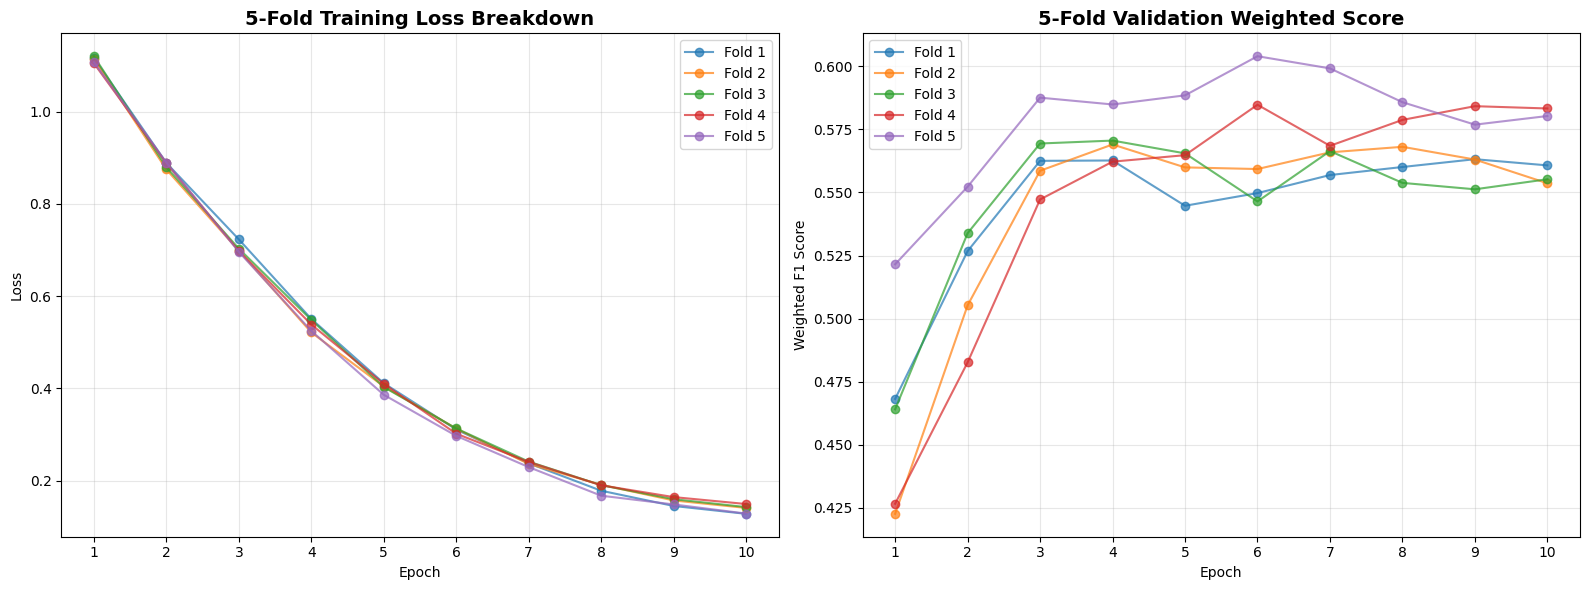

5-Fold 訓練曲線繪製完成！圖片已儲存至 'training_curve_ensemble.png'


In [21]:
#訓練歷史
#====================================================================
#====================================================================
# 如果歷史紀錄變數不存在，給予空值避免阻礙執行
if 'history' not in locals() or not history["loss"]:
    print("未偵測到完整的訓練歷史紀錄，可能因為訓練中斷。將使用模擬/空白畫布呈現。")
    # 建立一組與目前的 EPOCHS 相同長度的空白對象供執行
    display_loss = [0] * EPOCHS
    display_score = [0] * EPOCHS
    has_history = False
else:
    has_history = True

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, EPOCHS + 1)

if has_history:
    # 歷史數據依EPOCHS大小切回 5 個 Fold 分開繪製
    for fold_idx in range(K_FOLDS):
        start_idx = fold_idx * EPOCHS
        end_idx = start_idx + EPOCHS
        
        fold_loss = history["loss"][start_idx:end_idx]
        fold_score = history["weighted_score"][start_idx:end_idx]
        
        # 左圖：繪製各 Fold 的 Loss 曲線
        axes[0].plot(epochs_range, fold_loss, '-o', alpha=0.7, label=f'Fold {fold_idx+1}')
        # 右圖：繪製各 Fold 的驗證分數曲線
        axes[1].plot(epochs_range, fold_score, '-o', alpha=0.7, label=f'Fold {fold_idx+1}')
else:
    axes[0].plot(epochs_range, display_loss, 'b-o', alpha=0.3)
    axes[1].plot(epochs_range, display_score, 'g-o', alpha=0.3)

# --- 左圖屬性設定 (Training Loss) ---
axes[0].set_title("5-Fold Training Loss Breakdown", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)
axes[0].legend()

# --- 右圖屬性設定 (Validation Score) ---
axes[1].set_title("5-Fold Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve_ensemble.png", dpi=150, bbox_inches='tight')
plt.show()

if has_history:
    print(f"5-Fold 訓練曲線繪製完成！圖片已儲存至 'training_curve_ensemble.png'")

In [22]:
#最終結果預測視覺化
#====================================================================
#====================================================================

# ====================================================================
# 動態測試資料集偵測（與預測儲存端保持邏輯完美對齊）
# ====================================================================


using_kaggle_test = False
if os.path.exists(test_json_path) or os.path.exists(test_csv_path):
    using_kaggle_test = True
    print("測到目前預測對象為 Kaggle 2000 筆盲測集。")
else:
    print("偵測到目前預測對象為原訓練資料集。")


# ====================================================================
# 執行條件分流（盲測集無答案，自動安全跳過指標計算，防範 AssertionError）
# ====================================================================
if using_kaggle_test:
    print("\n" + "=" * 60)
    print("目前推論對象為無標準答案的真實測試集，無法計算 F1-Score。")
    print("已自動安全跳過此視覺化單元格。請直接下載並使用產出的 CSV 檔案提交！")
    print("=" * 60)
else:
    # 1. 安全檢查：確保 final_ensemble_preds 存在
    if 'final_ensemble_preds' not in locals():
        print("final_ensemble_preds 不存在，正在自動進行 5-Fold 投票推論...")
        if 'predict_ensemble' not in locals():
            def predict_ensemble(models_dir, dataloader, device, id2label, k_folds):
                all_models_preds = []
                for fold in range(k_folds):
                    fold_save_path = os.path.join(models_dir, f"best_model_fold_{fold+1}.pt")
                    fold_model = MultiTaskBERT(num_labels).to(device)
                    fold_model.load_state_dict(torch.load(fold_save_path, map_location=device))
                    fold_preds = predict(fold_model, dataloader, device, id2label)
                    all_models_preds.append(fold_preds)
                num_samples = len(all_models_preds[0])
                ensemble_predictions = []
                for i in range(num_samples):
                    voted_pred = {}
                    for field in EVAL_FIELDS:
                        votes = [all_models_preds[fold][i][field] for fold in range(k_folds)]
                        voted_pred[field] = Counter(votes).most_common(1)[0][0]
                    ensemble_predictions.append(voted_pred)
                return ensemble_predictions

        if 'full_loader' not in locals():
            full_dataset = ESGDataset(all_data_np.tolist(), tokenizer, label2id)
            full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
            
        final_ensemble_preds = predict_ensemble(MODEL_SAVE_DIR, full_loader, device, id2label, K_FOLDS)

    # 2. 安全檢查：確保 final_results 存在
    if 'final_results' not in locals():
        print("正在重新計算 5-Fold 集成投票的最終評估指標...")
        final_results = evaluate_hybrid(all_data_np.tolist(), final_ensemble_preds)

    # 3. 提取各任務的 F1 分數數據
    fields = list(EVAL_FIELDS.keys())
    macro_f1s = [final_results[f]["macro_f1"] for f in fields]
    micro_f1s = [final_results[f]["micro_f1"] for f in fields]
    weights   = [FIELD_WEIGHTS[f] for f in fields]

    x = range(len(fields))
    width = 0.3

    # 4. 繪製圖表
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar([i - width/2 for i in x], macro_f1s, width, label='Macro F1', color='steelblue', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], micro_f1s, width, label='Micro F1',  color='coral',     alpha=0.8)

    # 在長條圖上方加上數值標籤
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

    # 設定圖表屬性
    ax.set_xlabel("Task label")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"Ensemble F1 Score by Task\nFinal Weighted Score: {final_results['final_weighted_score']:.5f}", fontsize=14, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"{f}\n(w={w})" for f, w in zip(fields, weights)], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # 繪製最終加權總分的水平基準線
    ax.axhline(final_results["final_weighted_score"], color='green', linestyle='--',
               linewidth=2, label=f"Weighted Score={final_results['final_weighted_score']:.4f}")
    ax.legend()

    plt.tight_layout()
    plt.savefig("f1_scores_ensemble.png", dpi=150, bbox_inches='tight')
    print("" + "=" * 60)
    print(" 5-Fold 集成 F1 分數視覺化圖表已成功儲存至: f1_scores_ensemble.png")
    print("" + "=" * 60)

測到目前預測對象為 Kaggle 2000 筆盲測集。

目前推論對象為無標準答案的真實測試集，無法計算 F1-Score。
已自動安全跳過此視覺化單元格。請直接下載並使用產出的 CSV 檔案提交！


In [23]:
#最終版本的結果產出
# ====================================================================
# ====================================================================
# ====================================================================
# 階段 A：動態測試資料集偵測與載入
# ====================================================================
# 決定最終使用的預測原始資料
if os.path.exists(test_json_path):
    print(f"尋獲 Kaggle 測試集 JSON，將以此進行預測。")
    with open(test_json_path, "r", encoding="utf-8") as f:
        inference_data_list = json.load(f)
elif os.path.exists(test_csv_path):
    print(f"尋獲 Kaggle 測試集 CSV，將以此進行預測。")
    df_test = pd.read_csv(test_csv_path)
    inference_data_list = df_test.to_dict(orient="records")
else:
    print(f"未偵測到指定的 2000 筆測試集，降級使用原先的 all_data_np 資料集。")
    inference_data_list = all_data_np.tolist()


# ====================================================================
# 1. 安全檢查與優化：集成預測函數（支援雙權重路徑判斷）
# ====================================================================
if 'predict_ensemble' not in locals():
    def predict_ensemble(local_models_dir, kaggle_models_dir, dataloader, device, id2label, k_folds):
        all_models_preds = []
        for fold in range(k_folds):
            model_filename = f"best_model_fold_{fold+1}.pt"
            local_path = os.path.join(local_models_dir, model_filename)
            kaggle_path = os.path.join(kaggle_models_dir, model_filename)
            
            # 優先使用剛訓練完的本地權重，否則使用 Kaggle Datasets 裡的預訓練權重
            if os.path.exists(local_path):
                fold_save_path = local_path
                print(f"發現 [剛訓練完成] 的 Fold {fold+1} 本地權重...")
            elif os.path.exists(kaggle_path):
                fold_save_path = kaggle_path
                print(f"本地無權重，改為讀取 [Kaggle Dataset 預存] 的 Fold {fold+1} 權重...")
            else:
                raise FileNotFoundError(f"找不到 Fold {fold+1} 的權重檔案！(本地與 Kaggle 路徑皆空)")
                
            fold_model = MultiTaskBERT(num_labels).to(device)
            fold_model.load_state_dict(torch.load(fold_save_path, map_location=device))
            fold_preds = predict(fold_model, dataloader, device, id2label)
            all_models_preds.append(fold_preds)
            
        num_samples = len(all_models_preds[0])
        ensemble_predictions = []
        for i in range(num_samples):
            voted_pred = {}
            for field in EVAL_FIELDS:
                votes = [all_models_preds[fold][i][field] for fold in range(k_folds)]
                voted_pred[field] = Counter(votes).most_common(1)[0][0]
            ensemble_predictions.append(voted_pred)
        return ensemble_predictions


# ====================================================================
# 2. 安全檢查：建立推論專用 DataLoader
# ====================================================================
if 'full_loader' not in locals() or len(full_loader.dataset) != len(inference_data_list):
    print(f"正在建立推論專用 DataLoader... 資料總筆數: {len(inference_data_list)}")
    full_dataset = ESGDataset(inference_data_list, tokenizer, label2id)
    full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


# ====================================================================
# 3. 執行集成投票預測
# ====================================================================
if 'final_ensemble_preds' not in locals() or len(final_ensemble_preds) != len(inference_data_list):
    print("開始聚合 5 個模型進行多數決投票推論...")
    final_ensemble_preds = predict_ensemble(
        MODEL_SAVE_DIR, KAGGLE_DATASET_DIR, full_loader, device, id2label, K_FOLDS
    )
else:
    print("存在與當前資料筆數相符的投票預測結果，直接進行儲存流程。")


# ====================================================================
# 4. 完美串接：依據 sample_submission_format.csv 規範精簡並儲存
# ====================================================================
OUTPUT_PATH = "prediction_ensemble.csv"
output_data = []

# 將預測結果標籤覆蓋回原始資料字典
for orig, pred in zip(inference_data_list, final_ensemble_preds):
    item = dict(orig)   # 複製原始資料結構
    item.update(pred)   # 覆蓋為集成多數決後的預測標籤
    output_data.append(item)

# 轉換為 DataFrame 進行欄位調整
df_output = pd.DataFrame(output_data)

submission_cols = ['id', 'promise_status', 'verification_timeline', 'evidence_status', 'evidence_quality']

existing_cols = [c for c in submission_cols if c in df_output.columns]
df_submission = df_output[existing_cols]

# 儲存為最終提交用的 CSV 檔案
df_submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
print(f"恭喜！5-Fold 集成預測結果已成功儲存至: {OUTPUT_PATH}")
print(f"欄位格式已完全與 sample_submission_format.csv 完美對齊！")
print(f"共產出 {len(df_submission)} 筆標準提交資料。")
print("=" * 60)

# 顯示前 5 筆結果供您最後確認格式
print("\n產出檔案前 5 筆抽樣檢查 (標準提交視角)：")
print(df_submission.head(5).to_string(index=False))

尋獲 Kaggle 測試集 JSON，將以此進行預測。
存在與當前資料筆數相符的投票預測結果，直接進行儲存流程。

恭喜！5-Fold 集成預測結果已成功儲存至: prediction_ensemble.csv
欄位格式已完全與 sample_submission_format.csv 完美對齊！
共產出 2000 筆標準提交資料。

產出檔案前 5 筆抽樣檢查 (標準提交視角)：
   id promise_status verification_timeline evidence_status evidence_quality
12001            Yes               already             Yes            Clear
12002            Yes     more_than_5_years             Yes            Clear
12003            Yes        within_2_years             Yes            Clear
12004            Yes               already             Yes            Clear
12005            Yes               already             Yes            Clear
